## New Code

In [ ]:
"""Full reproduction toolkit for:
Albi, Calzola, Piu (2025)
Control of kinetic opinion dynamics in popularity-adaptive social networks.

This module implements:
- Model definitions and parameters (Table 1)
- Nanbu-like asymptotic particle scheme (Algorithm 1)
- Three numerical tests from Section 4
- Figure builders for Figures 1-11
"""

from __future__ import annotations

from dataclasses import dataclass, field, replace
from typing import Callable, Dict, Iterable, List, Mapping, Optional, Sequence, Tuple

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from tqdm.auto import tqdm
from scipy.ndimage import gaussian_filter, gaussian_filter1d


# Group labels
MASS = 0
LEADER = 1
LEADER_A = 1
LEADER_B = 2


@dataclass
class BaseParams:
    # Contacts dynamics
    beta: float = 1.0
    mu: float = 0.0
    c_bar: float = 200.0
    theta: float = 2.0
    delta_phi: float = 0.1
    nu: float = 0.1

    # Contact control
    gamma_c: float = 1.0
    lam: float = 1.0
    alpha_R: float = 0.1
    alpha_H: float = 0.1
    r: float = 0.7
    rho_star: float = 0.5
    c_min: float = 100.0

    # Opinion dynamics
    alpha: float = 1.0
    delta: float = 0.8
    p: float = 3.0
    v_tilde: float = 0.5
    sigma: float = 0.1

    # Opinion control
    gamma_v: float = 10.0


@dataclass
class RuntimeConfig:
    T: float
    dt: float
    Ns: int
    pair_fraction: float = 1.0
    v_bins: int = 220
    c_bins: int = 220
    c_max: float = 300.0
    c_clip_max: Optional[float] = None
    rho_bins: int = 320
    c_floor: float = 1e-8
    eta_dist: str = "uniform"
    phi_mean_mode: str = "dynamic"
    pair_mode: str = "matching"
    influence_mode: str = "partner"
    joint_smooth_sigma: float = 1.1
    marginal_smooth_sigma: float = 1.0
    seed: int = 1234


@dataclass
class ScenarioControl:
    key: str
    title: str
    contact_groups: Tuple[int, ...] = ()
    opinion_groups: Tuple[int, ...] = ()
    gamma_v_by_group: Dict[int, float] = field(default_factory=dict)
    target_by_group: Dict[int, float] = field(default_factory=dict)


def table1_params() -> BaseParams:
    """Parameters exactly as reported in Table 1 (PDF provided by user)."""
    return BaseParams(
        beta=1.0,
        mu=0.0,
        c_bar=200.0,
        theta=2.0,
        delta_phi=0.1,
        nu=0.1,
        gamma_c=1.0,
        lam=1.0,
        alpha_R=0.1,
        alpha_H=0.1,
        r=0.7,
        rho_star=0.5,
        c_min=100.0,
        alpha=1.0,
        delta=0.8,
        p=3.0,
        v_tilde=0.5,
        sigma=0.1,
        gamma_v=10.0,
    )


def params_for_test(test_id: int, variant: str = "figure") -> BaseParams:
    """Parameter profile selector.

    variant:
    - "paper": strict Table 1 values
    - "figure": calibrated profile that matches the published Test 2-3 figures
    """
    p = table1_params()
    variant = variant.lower()
    if variant == "paper":
        return p
    if variant == "figure":
        # Figure-consistent calibration from direct panel matching:
        # - Test 2: theta=0.2 best reproduces Fig. 7-8 polarization patterns.
        # - Test 3: theta=0.05 with a fixed reference mean m*=0 (see run_test3)
        #   best reproduces Fig. 10-11 long-time structures.
        if test_id == 2:
            p.theta = 0.2
        elif test_id == 3:
            p.theta = 0.05
        return p
    raise ValueError(f"Unknown variant: {variant}")


def make_runtime(test_id: int, mode: str = "fast", seed: int = 1234) -> RuntimeConfig:
    """Build runtime configs.

    mode options:
    - fast: quick qualitative runs
    - balanced: closer to paper but still notebook-friendly
    - paper: values as in paper (very expensive)
    """
    mode = mode.lower()
    if mode not in {"fast", "balanced", "paper"}:
        raise ValueError(f"Unknown mode: {mode}")

    if test_id in {1, 2}:
        T = 50.0
    elif test_id == 3:
        T = 150.0
    else:
        raise ValueError("test_id must be 1, 2, or 3")

    if mode == "fast":
        # Keep runs practical in pure NumPy while preserving qualitative behavior.
        if test_id == 1:
            return RuntimeConfig(T=T, dt=1e-2, Ns=12_000, pair_fraction=1.0, seed=seed)
        if test_id == 2:
            return RuntimeConfig(T=T, dt=1e-2, Ns=16_000, pair_fraction=1.0, seed=seed)
        return RuntimeConfig(T=T, dt=1e-2, Ns=18_000, pair_fraction=1.0, seed=seed)
    if mode == "balanced":
        if test_id == 1:
            return RuntimeConfig(T=T, dt=1e-2, Ns=24_000, pair_fraction=1.0, seed=seed)
        if test_id == 2:
            return RuntimeConfig(T=T, dt=1e-2, Ns=30_000, pair_fraction=1.0, seed=seed)
        # Test 3 is the most sensitive to Monte-Carlo noise in late-time branch patterns.
        # A moderately larger Ns improves figure-to-paper agreement without changing equations.
        return RuntimeConfig(T=T, dt=1e-2, Ns=60_000, pair_fraction=1.0, seed=seed)
    # paper
    return RuntimeConfig(T=T, dt=1e-3, Ns=1_000_000, pair_fraction=1.0, seed=seed)


def sigmoid(x: np.ndarray) -> np.ndarray:
    x = np.clip(x, -60.0, 60.0)
    return 1.0 / (1.0 + np.exp(-x))


def psi_eps(s: np.ndarray, beta: float, mu: float, eps: float) -> np.ndarray:
    """Prospect-theory-inspired value function Psi^eps(s), Eq. (page 5).

    Psi^eps(s) = 1/beta * (mu/(1-mu)) * (s^eps - 1) / (((1+mu)/(1-mu))*s^eps + 1)
    """
    s = np.maximum(s, 1e-12)
    if abs(mu) < 1e-14:
        return np.zeros_like(s)

    s_eps = np.power(s, eps)
    num = s_eps - 1.0
    den = ((1.0 + mu) / (1.0 - mu)) * s_eps + 1.0
    return (1.0 / (beta *eps) ) * (mu / (1.0 - mu)) * (num / den)


def phi_v(v: np.ndarray, m_v: float, theta: float, delta_phi: float) -> np.ndarray:
    """Endogenous opinion-based contacts modulation Phi(v), page 3."""
    return theta * ((v - m_v) ** 2 - delta_phi**2)


def Rc(c: np.ndarray, alpha_R: float, c_min: float) -> np.ndarray:
    """Contact activation sigmoid, Eq. (page 4)."""
    return sigmoid(alpha_R * (c_min - c))


def Hc_from_rho(rho: np.ndarray, alpha_H: float, rho_star: float) -> np.ndarray:
    """Opinion-cluster activation sigmoid for contact control, Eq. (page 4)."""
    return sigmoid(alpha_H * (rho - rho_star))


def D(v: np.ndarray) -> np.ndarray:
    """Self-diffusion for opinions, D(v)=1-v^2."""
    return 1.0 - v**2


class LocalMassEstimator:
    """Fast approximation of rho(v)=int_{|w-v|<=r} f(w,c,t)dw dc using bins."""

    def __init__(self, r: float, n_bins: int = 320, v_min: float = -1.0, v_max: float = 1.0):
        self.r = float(r)
        self.n_bins = int(n_bins)
        self.v_min = float(v_min)
        self.v_max = float(v_max)
        self.edges = np.linspace(v_min, v_max, n_bins + 1)
        self.dv = self.edges[1] - self.edges[0]
        self.window = max(0, int(np.ceil(self.r / self.dv)))

    def __call__(self, v: np.ndarray) -> np.ndarray:
        idx = np.searchsorted(self.edges, v, side="right") - 1
        idx = np.clip(idx, 0, self.n_bins - 1)
        counts = np.bincount(idx, minlength=self.n_bins).astype(np.float64)
        N = float(v.size)

        # Sliding window sum via cumulative sum
        csum = np.concatenate(([0.0], np.cumsum(counts)))
        bins = np.arange(self.n_bins)
        left = np.maximum(bins - self.window, 0)
        right = np.minimum(bins + self.window + 1, self.n_bins)
        rho_bins = (csum[right] - csum[left]) / max(N, 1.0)

        return rho_bins[idx]


def compromise_terms(
    vi: np.ndarray,
    vj: np.ndarray,
    ci: np.ndarray,
    cj: np.ndarray,
    delta: float,
    p: float,
    mode: str = "partner",
) -> Tuple[np.ndarray, np.ndarray]:
    """Return P_ij and P_ji for paired particles."""
    close = (np.abs(vi - vj) < delta).astype(np.float64)

    ci_p = np.power(np.maximum(ci, 1e-12), p)
    cj_p = np.power(np.maximum(cj, 1e-12), p)
    den = ci_p + cj_p + 1e-14

    # In the numerical tests, a partner-weighted compromise reproduces the published figures:
    # P_ij ~ c_j^p/(c_i^p + c_j^p), P_ji ~ c_i^p/(c_i^p + c_j^p).
    # Keep "self" mode for strict literal interpretation of K(c,c*) in Section 3.
    if mode == "partner":
        K_ij = cj_p / den
        K_ji = ci_p / den
    elif mode == "self":
        K_ij = ci_p / den
        K_ji = cj_p / den
    else:
        raise ValueError(f"Unknown influence_mode: {mode}")

    return close * K_ij, close * K_ji


def make_edges(cfg: RuntimeConfig) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    v_edges = np.linspace(-1.0, 1.0, cfg.v_bins + 1)
    c_edges = np.linspace(0.0, cfg.c_max, cfg.c_bins + 1)
    v_centers = 0.5 * (v_edges[:-1] + v_edges[1:])
    c_centers = 0.5 * (c_edges[:-1] + c_edges[1:])
    return v_edges, c_edges, v_centers, c_centers


def joint_density(
    v: np.ndarray,
    c: np.ndarray,
    v_edges: np.ndarray,
    c_edges: np.ndarray,
    smooth_sigma: float = 0.0,
) -> np.ndarray:
    H, _, _ = np.histogram2d(v, c, bins=[v_edges, c_edges], density=False)
    if smooth_sigma > 0.0:
        H = gaussian_filter(H, sigma=float(smooth_sigma), mode="nearest")

    dv = v_edges[1] - v_edges[0]
    dc = c_edges[1] - c_edges[0]
    mass = max(float(v.size), 1.0)
    H = H / (mass * dv * dc)
    return H


def marginal_density(x: np.ndarray, edges: np.ndarray, smooth_sigma: float = 0.0) -> np.ndarray:
    h, _ = np.histogram(x, bins=edges, density=False)
    if smooth_sigma > 0.0:
        h = gaussian_filter1d(h.astype(np.float64), sigma=float(smooth_sigma), mode="nearest")

    dx = edges[1] - edges[0]
    mass = max(float(x.size), 1.0)
    h = h / (mass * dx)
    return h


def _time_map(times: Sequence[float], dt: float) -> Dict[int, float]:
    out: Dict[int, float] = {}
    for t in times:
        out[int(round(float(t) / dt))] = float(t)
    return out


def run_particle_simulation(
    v0: np.ndarray,
    c0: np.ndarray,
    groups: np.ndarray,
    params: BaseParams,
    cfg: RuntimeConfig,
    scenario: ScenarioControl,
    snapshot_times: Sequence[float],
    marginal_times: Sequence[float],
    progress: bool = True,
) -> Dict[str, object]:
    """Run one scenario with Algorithm 1 (Nanbu-like).

    Notes:
    - We keep the structure in page 9 (paired updates, epsilon=dt)
    - For local mass rho(v) we use a bin-based approximation for efficiency
    """
    rng = np.random.default_rng(cfg.seed)

    v = v0.copy().astype(np.float64)
    c = c0.copy().astype(np.float64)
    g = groups.copy().astype(np.int32)

    N = v.size
    Nt = int(round(cfg.T / cfg.dt))
    eps = cfg.dt
    

    n_pairs = int(round(0.5 * cfg.pair_fraction * N))
    n_pairs = max(1, min(n_pairs, N // 2))

    v_edges, c_edges, v_centers, c_centers = make_edges(cfg)

    snapshot_steps = _time_map(snapshot_times, cfg.dt)
    marginal_steps = _time_map(marginal_times, cfg.dt)

    joint_snapshots: Dict[float, np.ndarray] = {}
    contact_snapshots: Dict[float, np.ndarray] = {}
    opinion_snapshots: Dict[float, np.ndarray] = {}

    # Include initial state if requested in times
    if 0 in snapshot_steps:
        joint_snapshots[snapshot_steps[0]] = joint_density(
            v, c, v_edges, c_edges, smooth_sigma=cfg.joint_smooth_sigma
        )
    if 0 in marginal_steps:
        contact_snapshots[marginal_steps[0]] = marginal_density(
            c, c_edges, smooth_sigma=cfg.marginal_smooth_sigma
        )
        opinion_snapshots[marginal_steps[0]] = marginal_density(
            v, v_edges, smooth_sigma=cfg.marginal_smooth_sigma
        )

    mc = np.empty(Nt + 1, dtype=np.float64)
    mv = np.empty(Nt + 1, dtype=np.float64)
    mc[0] = np.mean(c)
    mv[0] = np.mean(v)

    # Static masks and per-group control parameters
    contact_enabled = np.isin(g, np.array(scenario.contact_groups, dtype=np.int32))
    opinion_enabled = np.isin(g, np.array(scenario.opinion_groups, dtype=np.int32))

    gamma_v_arr = np.full(N, params.gamma_v, dtype=np.float64)
    target_arr = np.full(N, params.v_tilde, dtype=np.float64)

    for key, val in scenario.gamma_v_by_group.items():
        gamma_v_arr[g == key] = float(val)
    for key, val in scenario.target_by_group.items():
        target_arr[g == key] = float(val)

    rho_est = LocalMassEstimator(r=params.r, n_bins=cfg.rho_bins)
    m_v0 = float(np.mean(v))

    iterator = range(Nt)
    if progress:
        iterator = tqdm(iterator, desc=f"Scenario {scenario.key}", leave=False)

    sqrt_eps = np.sqrt(eps)

    for n in iterator:
        if cfg.pair_mode == "matching":
            # Disjoint pairing from a random permutation (each selected particle updated once).
            perm = rng.permutation(N)
            paired = perm[: 2 * n_pairs].reshape(n_pairs, 2)
            i = paired[:, 0]
            j = paired[:, 1]
        elif cfg.pair_mode == "with_replacement":
            # Random unordered pairs sampled in index-space with particle repetitions allowed.
            i = rng.integers(0, N, size=n_pairs)
            j = rng.integers(0, N, size=n_pairs)
            same = i == j
            while np.any(same):
                j[same] = rng.integers(0, N, size=int(np.sum(same)))
                same = i == j
        else:
            raise ValueError(f"Unknown pair_mode: {cfg.pair_mode}")

        vi = v[i]
        vj = v[j]
        ci = c[i]
        cj = c[j]

        if cfg.phi_mean_mode == "dynamic":
            m_v = float(np.mean(v))
        elif cfg.phi_mean_mode == "initial":
            m_v = m_v0
        elif cfg.phi_mean_mode == "zero":
            m_v = 0.0
        else:
            raise ValueError(f"Unknown phi_mean_mode: {cfg.phi_mean_mode}")
        phi_i = phi_v(vi, m_v, params.theta, params.delta_phi)
        phi_j = phi_v(vj, m_v, params.theta, params.delta_phi)

        # Contact control
        kappa_i = np.zeros(n_pairs, dtype=np.float64)
        kappa_j = np.zeros(n_pairs, dtype=np.float64)

        if np.any(contact_enabled):
            rho_all = rho_est(v)
            hc_all = Hc_from_rho(rho_all, params.alpha_H, params.rho_star)

            rc_i = Rc(ci, params.alpha_R, params.c_min)
            rc_j = Rc(cj, params.alpha_R, params.c_min)

            kappa_pref = params.lam * params.beta / params.gamma_c
            kappa_i = kappa_pref * rc_i * hc_all[i] * contact_enabled[i].astype(np.float64)
            kappa_j = kappa_pref * rc_j * hc_all[j] * contact_enabled[j].astype(np.float64)

        # Opinion compromise and control
        Pij, Pji = compromise_terms(
            vi, vj, ci, cj, params.delta, params.p, mode=cfg.influence_mode
        )

        u_i = np.zeros(n_pairs, dtype=np.float64)
        u_j = np.zeros(n_pairs, dtype=np.float64)

        if np.any(opinion_enabled):
            # Table 1 uses Rv(c)=Hv(v)=1 in experiments
            rvhv_i = np.ones(n_pairs, dtype=np.float64)
            rvhv_j = np.ones(n_pairs, dtype=np.float64)

            term_i = vi + eps * params.alpha * Pij * (vj - vi) - target_arr[i]
            term_j = vj + eps * params.alpha * Pji * (vi - vj) - target_arr[j]

            den_i = gamma_v_arr[i] + eps * params.alpha * rvhv_i
            den_j = gamma_v_arr[j] + eps * params.alpha * rvhv_j

            u_i = -(rvhv_i * term_i) / den_i
            u_j = -(rvhv_j * term_j) / den_j

            u_i *= opinion_enabled[i].astype(np.float64)
            u_j *= opinion_enabled[j].astype(np.float64)

        # Noises
        # The paper constrains eta by moments and positivity consistency (not strictly Gaussian).
        # We therefore default to a bounded distribution with the same variance E[eta^2]=eps*nu^2.
        if cfg.eta_dist == "uniform":
            amp = np.sqrt(3.0) * sqrt_eps * params.nu
            eta_i = amp * rng.uniform(-1.0, 1.0, size=n_pairs)
            eta_j = amp * rng.uniform(-1.0, 1.0, size=n_pairs)
        elif cfg.eta_dist == "rademacher":
            amp = sqrt_eps * params.nu
            eta_i = amp * rng.choice(np.array([-1.0, 1.0]), size=n_pairs)
            eta_j = amp * rng.choice(np.array([-1.0, 1.0]), size=n_pairs)
        elif cfg.eta_dist == "normal":
            eta_i = sqrt_eps * params.nu * rng.normal(size=n_pairs)
            eta_j = sqrt_eps * params.nu * rng.normal(size=n_pairs)
        else:
            raise ValueError(f"Unknown eta_dist: {cfg.eta_dist}")
        xi_i = rng.normal(size=n_pairs)
        xi_j = rng.normal(size=n_pairs)

        # Update contacts
        ci_new = ci - eps * params.beta * (psi_eps(ci / params.c_bar, params.beta, params.mu, eps) + phi_i - kappa_i) * ci + eta_i * ci
        cj_new = cj - eps * params.beta * (psi_eps(cj / params.c_bar, params.beta, params.mu, eps) + phi_j - kappa_j) * cj + eta_j * cj

        if cfg.c_clip_max is None:
            ci_new = np.maximum(ci_new, cfg.c_floor)
            cj_new = np.maximum(cj_new, cfg.c_floor)
        else:
            ci_new = np.clip(ci_new, cfg.c_floor, cfg.c_clip_max)
            cj_new = np.clip(cj_new, cfg.c_floor, cfg.c_clip_max)

        # Update opinions (vectorized: interact is 1 if |vi-vj|<eps, else 0)
        # interact = (np.abs(vi - vj) < params.delta).astype(np.float64)

        # vi_new = vi + eps * params.alpha * (Pij * interact + u_i) + sqrt_eps * params.sigma * D(vi) * xi_i
        # vj_new = vj + eps * params.alpha * (Pji * interact + u_j) + sqrt_eps * params.sigma * D(vj) * xi_j

        #Update opinions
        vi_new = vi + eps * params.alpha * (Pij * (vj - vi) + u_i) + sqrt_eps * params.sigma * D(vi) * xi_i
        vj_new = vj + eps * params.alpha * (Pji * (vi - vj) + u_j) + sqrt_eps * params.sigma * D(vj) * xi_j


        # if abs(vi-vj)< eps:
        #     vi_new = vi + eps * params.alpha * (Pij * 1 + u_i) + sqrt_eps * params.sigma * D(vi) * xi_i
        #     vj_new = vj + eps * params.alpha * (Pji * 1 + u_j) + sqrt_eps * params.sigma * D(vj) * xi_j
        # else:
        #     vi_new = vi + eps * params.alpha * (Pij * 0 + u_i) + sqrt_eps * params.sigma * D(vi) * xi_i
        #     vj_new = vj + eps * params.alpha * (Pji * 0 + u_j) + sqrt_eps * params.sigma * D(vj) * xi_j

        vi_new = np.clip(vi_new, -1.0, 1.0)
        vj_new = np.clip(vj_new, -1.0, 1.0)

        c[i] = ci_new
        c[j] = cj_new
        v[i] = vi_new
        v[j] = vj_new

        mc[n + 1] = np.mean(c)
        mv[n + 1] = np.mean(v)

        step = n + 1
        if step in snapshot_steps:
            t = snapshot_steps[step]
            joint_snapshots[t] = joint_density(
                v, c, v_edges, c_edges, smooth_sigma=cfg.joint_smooth_sigma
            )
        if step in marginal_steps:
            t = marginal_steps[step]
            contact_snapshots[t] = marginal_density(
                c, c_edges, smooth_sigma=cfg.marginal_smooth_sigma
            )
            opinion_snapshots[t] = marginal_density(
                v, v_edges, smooth_sigma=cfg.marginal_smooth_sigma
            )

    times = np.arange(Nt + 1, dtype=np.float64) * cfg.dt

    return {
        "scenario": scenario,
        "v_edges": v_edges,
        "c_edges": c_edges,
        "v_centers": v_centers,
        "c_centers": c_centers,
        "times": times,
        "mc": mc,
        "mv": mv,
        "joint": joint_snapshots,
        "contact_marginals": contact_snapshots,
        "opinion_marginals": opinion_snapshots,
        "final_v": v,
        "final_c": c,
        "groups": g,
    }


def init_test1(Ns: int, seed: int = 1234) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Test 1 initial condition, page 10-11.

    - 25% leaders: c~U[150,200], v~U[0.4,0.6]
    - 75% mass:    c~U[10,90],  v~U[-0.9,-0.1]
    """
    rng = np.random.default_rng(seed)

    n_lead = int(round(0.25 * Ns))
    n_mass = Ns - n_lead

    v = np.empty(Ns, dtype=np.float64)
    c = np.empty(Ns, dtype=np.float64)
    g = np.empty(Ns, dtype=np.int32)

    c[:n_lead] = rng.uniform(150.0, 200.0, size=n_lead)
    v[:n_lead] = rng.uniform(0.4, 0.6, size=n_lead)
    g[:n_lead] = LEADER

    c[n_lead:] = rng.uniform(10.0, 90.0, size=n_mass)
    v[n_lead:] = rng.uniform(-0.9, -0.1, size=n_mass)
    g[n_lead:] = MASS

    perm = rng.permutation(Ns)
    return v[perm], c[perm], g[perm]


def init_test2(Ns: int, seed: int = 1234) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Test 2 initial condition, page 11.

    - 25% group A: c~U[200,250], v~U[-0.6,-0.4]
    - 25% group B: c~U[200,250], v~U[0.4,0.6]
    - 50% mass:    c~U[50,100],  v~U[-0.8,0.8]
    """
    rng = np.random.default_rng(seed)

    n_a = int(round(0.25 * Ns))
    n_b = int(round(0.25 * Ns))
    n_mass = Ns - n_a - n_b

    v = np.empty(Ns, dtype=np.float64)
    c = np.empty(Ns, dtype=np.float64)
    g = np.empty(Ns, dtype=np.int32)

    c[:n_a] = rng.uniform(200.0, 250.0, size=n_a)
    v[:n_a] = rng.uniform(-0.6, -0.4, size=n_a)
    g[:n_a] = LEADER_A

    st = n_a
    en = n_a + n_b
    c[st:en] = rng.uniform(200.0, 250.0, size=n_b)
    v[st:en] = rng.uniform(0.4, 0.6, size=n_b)
    g[st:en] = LEADER_B

    c[en:] = rng.uniform(50.0, 100.0, size=n_mass)
    v[en:] = rng.uniform(-0.8, 0.8, size=n_mass)
    g[en:] = MASS

    perm = rng.permutation(Ns)
    return v[perm], c[perm], g[perm]


def init_test3(Ns: int, seed: int = 1234) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Test 3 initial condition, page 14.

    - 25% group A: c~U[200,250], v~U[-0.6,-0.4]
    - 25% group B: c~U[200,250], v~U[0.4,0.6]
    - 50% mass:    c~U[50,100],  v~U[0.1,0.6]
    """
    rng = np.random.default_rng(seed)

    n_a = int(round(0.25 * Ns))
    n_b = int(round(0.25 * Ns))
    n_mass = Ns - n_a - n_b

    v = np.empty(Ns, dtype=np.float64)
    c = np.empty(Ns, dtype=np.float64)
    g = np.empty(Ns, dtype=np.int32)

    c[:n_a] = rng.uniform(200.0, 250.0, size=n_a)
    v[:n_a] = rng.uniform(-0.6, -0.4, size=n_a)
    g[:n_a] = LEADER_A

    st = n_a
    en = n_a + n_b
    c[st:en] = rng.uniform(200.0, 250.0, size=n_b)
    v[st:en] = rng.uniform(0.4, 0.6, size=n_b)
    g[st:en] = LEADER_B

    c[en:] = rng.uniform(50.0, 100.0, size=n_mass)
    v[en:] = rng.uniform(0.1, 0.6, size=n_mass)
    g[en:] = MASS

    perm = rng.permutation(Ns)
    return v[perm], c[perm], g[perm]


def scenarios_test1(params: BaseParams) -> List[ScenarioControl]:
    return [
        ScenarioControl(key="a", title="(a) No control", contact_groups=(), opinion_groups=()),
        ScenarioControl(key="b", title="(b) Contact control on leaders", contact_groups=(LEADER,), opinion_groups=()),
        ScenarioControl(
            key="c",
            title="(c) Opinion control on leaders",
            contact_groups=(),
            opinion_groups=(LEADER,),
            gamma_v_by_group={LEADER: params.gamma_v},
            target_by_group={LEADER: params.v_tilde},
        ),
        ScenarioControl(
            key="d",
            title="(d) Joint contact+opinion control on leaders",
            contact_groups=(LEADER,),
            opinion_groups=(LEADER,),
            gamma_v_by_group={LEADER: params.gamma_v},
            target_by_group={LEADER: params.v_tilde},
        ),
    ]


def scenarios_test2() -> List[ScenarioControl]:
    return [
        ScenarioControl(key="a", title="(a) No control", contact_groups=(), opinion_groups=()),
        ScenarioControl(
            key="b",
            title="(b) Symmetric opinion control",
            contact_groups=(),
            opinion_groups=(LEADER_A, LEADER_B),
            gamma_v_by_group={LEADER_A: 1.0, LEADER_B: 1.0},
            target_by_group={LEADER_A: -0.5, LEADER_B: 0.5},
        ),
        ScenarioControl(
            key="c",
            title="(c) Non-symmetric opinion control",
            contact_groups=(),
            opinion_groups=(LEADER_A, LEADER_B),
            gamma_v_by_group={LEADER_A: 100.0, LEADER_B: 1.0},
            target_by_group={LEADER_A: -0.5, LEADER_B: 0.5},
        ),
    ]


def scenarios_test3() -> List[ScenarioControl]:
    return [
        ScenarioControl(
            key="a",
            title="(a) Control u* on Groups A and B",
            contact_groups=(),
            opinion_groups=(LEADER_A, LEADER_B),
            gamma_v_by_group={LEADER_A: 1.0, LEADER_B: 1.0},
            target_by_group={LEADER_A: -0.5, LEADER_B: 0.5},
        ),
        ScenarioControl(
            key="b",
            title="(b) Control u* on A,B and kappa* on A",
            contact_groups=(LEADER_A,),
            opinion_groups=(LEADER_A, LEADER_B),
            gamma_v_by_group={LEADER_A: 1.0, LEADER_B: 1.0},
            target_by_group={LEADER_A: -0.5, LEADER_B: 0.5},
        ),
        ScenarioControl(
            key="c",
            title="(c) Controls u* and kappa* on A and B",
            contact_groups=(LEADER_A, LEADER_B),
            opinion_groups=(LEADER_A, LEADER_B),
            gamma_v_by_group={LEADER_A: 1.0, LEADER_B: 1.0},
            target_by_group={LEADER_A: -0.5, LEADER_B: 0.5},
        ),
    ]


def run_experiment(
    init_fn: Callable[[int, int], Tuple[np.ndarray, np.ndarray, np.ndarray]],
    scenarios: Sequence[ScenarioControl],
    params: BaseParams,
    cfg: RuntimeConfig,
    snapshot_times: Sequence[float],
    marginal_times: Sequence[float],
    progress: bool = True,
) -> Dict[str, object]:
    """Run all scenarios for one test using the same initial sample."""
    v0, c0, g0 = init_fn(cfg.Ns, cfg.seed)
    v_edges, c_edges, v_centers, c_centers = make_edges(cfg)

    initial_joint = joint_density(
        v0, c0, v_edges, c_edges, smooth_sigma=cfg.joint_smooth_sigma
    )

    results: Dict[str, Dict[str, object]] = {}
    for k, sc in enumerate(scenarios):
        cfg_k = replace(cfg, seed=cfg.seed + 1000 * (k + 1))
        results[sc.key] = run_particle_simulation(
            v0=v0,
            c0=c0,
            groups=g0,
            params=params,
            cfg=cfg_k,
            scenario=sc,
            snapshot_times=snapshot_times,
            marginal_times=marginal_times,
            progress=progress,
        )

    return {
        "config": cfg,
        "params": params,
        "v0": v0,
        "c0": c0,
        "groups0": g0,
        "initial_joint": initial_joint,
        "scenarios": {s.key: s for s in scenarios},
        "results": results,
        "v_edges": v_edges,
        "c_edges": c_edges,
        "v_centers": v_centers,
        "c_centers": c_centers,
    }


def plot_figure1_psi(beta: float = 1.0, mu: float = 0.1, s_min: float = 0.05, s_max: float = 2.0) -> plt.Figure:
    """Figure 1 style plot of Psi(s) with asymptotic bounds."""
    s = np.linspace(s_min, s_max, 400)
    psi = psi_eps(s, beta=beta, mu=mu, eps=1.0)

    lower = -(1.0 / beta) * (mu / (1.0 - mu))
    upper = (1.0 / beta) * (mu / (1.0 + mu))

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(s, psi, lw=2.0, label=r"$\Psi(s)$")
    ax.axhline(0.0, color="gray", ls="--", lw=0.9)
    ax.axvline(1.0, color="gray", ls="--", lw=0.9)
    ax.axhline(lower, color="red", lw=1.2)
    ax.axhline(upper, color="red", lw=1.2)
    ax.set_xlabel(r"$s=c/\bar c$")
    ax.set_ylabel(r"$\Psi(s)$")
    ax.set_title("Figure 1 reproduction")
    ax.legend(loc="best")
    ax.grid(alpha=0.25)
    fig.tight_layout()
    return fig


def plot_initial_joint(exp: Mapping[str, object], title: str) -> plt.Figure:
    v_edges = exp["v_edges"]
    c_edges = exp["c_edges"]
    H0 = exp["initial_joint"]

    fig, ax = plt.subplots(figsize=(4.8, 4.4))
    pcm = ax.pcolormesh(v_edges, c_edges, H0.T, cmap="turbo", shading="auto")
    ax.set_xlabel(r"$v$")
    ax.set_ylabel(r"$c$")
    ax.set_title(title)
    cbar = fig.colorbar(pcm, ax=ax)
    cbar.set_label(r"$f(c,v,t)$")
    fig.tight_layout()
    return fig


def plot_joint_snapshots_grid(
    exp: Mapping[str, object],
    scenario_order: Sequence[str],
    times: Sequence[float],
    title: str,
    with_colorbar: bool = True,
    figsize: Optional[Tuple[float, float]] = None,
) -> plt.Figure:
    if figsize is None:
        figsize = (3.2 * len(times), 2.6 * len(scenario_order) + 0.6)

    v_edges = exp["v_edges"]
    c_edges = exp["c_edges"]

    fig, axes = plt.subplots(len(scenario_order), len(times), figsize=figsize, squeeze=False)

    for r, sk in enumerate(scenario_order):
        res = exp["results"][sk]
        sc_title = exp["scenarios"][sk].title
        for cidx, t in enumerate(times):
            ax = axes[r, cidx]
            if t not in res["joint"]:
                raise KeyError(f"Time t={t} not found in scenario {sk} joint snapshots")
            H = res["joint"][t]
            im = ax.pcolormesh(v_edges, c_edges, H.T, cmap="turbo", shading="auto")
            if r == 0:
                ax.set_title(f"t = {t:g}")
            if cidx == 0:
                ax.set_ylabel(f"{sc_title}\n$c$")
            else:
                ax.set_ylabel(r"$c$")
            ax.set_xlabel(r"$v$")
            if with_colorbar:
                cb = fig.colorbar(im, ax=ax, orientation="horizontal", pad=0.18, fraction=0.08)
                cb.ax.tick_params(labelsize=7)
                cb.set_label(r"$f(c,v,t)$", fontsize=8)

    fig.suptitle(title, y=1.01, fontsize=12)
    fig.tight_layout()
    return fig


def _stacked_lines_3d(
    ax: Axes3D,
    x: np.ndarray,
    t_values: Sequence[float],
    density_by_time: Mapping[float, np.ndarray],
    color: str,
    xlabel: str,
    zlabel: str,
    title: str,
) -> None:
    t_sorted = sorted(t_values)
    for t in t_sorted:
        if t not in density_by_time:
            continue
        d = density_by_time[t]
        y = np.full_like(x, t)
        ax.plot(x, y, d, color=color, lw=1.2, alpha=0.95)

    ax.set_title(title, fontsize=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r"$t$")
    ax.set_zlabel(zlabel)
    ax.view_init(elev=25, azim=-65)


def plot_marginal_3d_panels(
    exp: Mapping[str, object],
    scenario_order: Sequence[str],
    times: Sequence[float],
    title: str,
    figsize: Optional[Tuple[float, float]] = None,
) -> plt.Figure:
    if figsize is None:
        figsize = (12.0, 3.7 * len(scenario_order))

    v_centers = exp["v_centers"]
    c_centers = exp["c_centers"]

    fig = plt.figure(figsize=figsize)

    for r, sk in enumerate(scenario_order):
        res = exp["results"][sk]
        sc_title = exp["scenarios"][sk].title

        ax1 = fig.add_subplot(len(scenario_order), 2, 2 * r + 1, projection="3d")
        _stacked_lines_3d(
            ax=ax1,
            x=c_centers,
            t_values=times,
            density_by_time=res["contact_marginals"],
            color="royalblue",
            xlabel=r"$c$",
            zlabel=r"$h(c)$",
            title=f"{sc_title} | contacts",
        )

        ax2 = fig.add_subplot(len(scenario_order), 2, 2 * r + 2, projection="3d")
        _stacked_lines_3d(
            ax=ax2,
            x=v_centers,
            t_values=times,
            density_by_time=res["opinion_marginals"],
            color="firebrick",
            xlabel=r"$v$",
            zlabel=r"$g(v)$",
            title=f"{sc_title} | opinions",
        )

    fig.suptitle(title, y=0.995, fontsize=12)
    fig.tight_layout()
    return fig


def plot_test1_means(
    exp: Mapping[str, object],
    scenario_order: Sequence[str] = ("a", "b", "c", "d"),
    target_v: float = 0.5,
) -> plt.Figure:
    fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.2))

    colors = {"a": "tab:blue", "b": "tab:orange", "c": "tab:olive", "d": "tab:purple"}

    for sk in scenario_order:
        res = exp["results"][sk]
        t = res["times"]
        axes[0].plot(t, res["mc"], color=colors[sk], lw=2.0, label=sk)
        axes[1].plot(t, res["mv"], color=colors[sk], lw=2.0, label=sk)

    axes[0].set_title("Evolution of the mean contacts")
    axes[0].set_xlabel(r"$t$")
    axes[0].set_ylabel(r"$m_c(t)$")
    axes[0].grid(alpha=0.25)
    axes[0].legend(title="scenario")

    axes[1].set_title("Evolution of the mean opinions")
    axes[1].set_xlabel(r"$t$")
    axes[1].set_ylabel(r"$m_v(t)$")
    axes[1].axhline(target_v, color="gray", ls="--", lw=1.0)
    axes[1].text(exp["config"].T * 0.73, target_v + 0.02, "Target opinion", color="gray", fontsize=9)
    axes[1].grid(alpha=0.25)
    axes[1].legend(title="scenario")

    fig.tight_layout()
    return fig


def run_test1(
    mode: str = "fast",
    seed: int = 1234,
    progress: bool = True,
    variant: str = "figure",
) -> Dict[str, object]:
    params = params_for_test(1, variant=variant)
    cfg = make_runtime(test_id=1, mode=mode, seed=seed)
    if variant.lower() == "paper":
        # Literal reading of K(c,c*) in Section 3.
        cfg = replace(cfg, influence_mode="self")
    else:
        # Figure-consistent influence interpretation.
        cfg = replace(cfg, influence_mode="partner")
    sc = scenarios_test1(params)

    snapshot_times = [1.0, 5.0, 15.0, 50.0]
    marginal_times = [0.0, 1.0, 5.0, 15.0, 50.0]

    return run_experiment(
        init_fn=init_test1,
        scenarios=sc,
        params=params,
        cfg=cfg,
        snapshot_times=snapshot_times,
        marginal_times=marginal_times,
        progress=progress,
    )


def run_test2(
    mode: str = "fast",
    seed: int = 2222,
    progress: bool = True,
    variant: str = "figure",
) -> Dict[str, object]:
    params = params_for_test(2, variant=variant)
    cfg = make_runtime(test_id=2, mode=mode, seed=seed)
    if variant.lower() == "paper":
        cfg = replace(cfg, influence_mode="self")
    else:
        cfg = replace(cfg, influence_mode="partner")
    sc = scenarios_test2()

    # Use panel times as displayed in the PDF figure layout.
    snapshot_times = [1.0, 5.0, 15.0, 50.0]
    marginal_times = [0.0, 1.0, 5.0, 15.0, 50.0]

    return run_experiment(
        init_fn=init_test2,
        scenarios=sc,
        params=params,
        cfg=cfg,
        snapshot_times=snapshot_times,
        marginal_times=marginal_times,
        progress=progress,
    )


def run_test3(
    mode: str = "fast",
    seed: int = 3333,
    progress: bool = True,
    variant: str = "figure",
) -> Dict[str, object]:
    params = params_for_test(3, variant=variant)
    params.gamma_v = 1.0  # as stated for Test 3 on page 14
    cfg = make_runtime(test_id=3, mode=mode, seed=seed)
    if variant.lower() == "figure":
        # Interpreting m_* in Phi(v) as a fixed societal reference level (0)
        # gives better agreement with the published Figure 10/11 patterns.
        cfg = replace(cfg, phi_mean_mode="zero", influence_mode="partner")
    else:
        cfg = replace(cfg, influence_mode="self")
    sc = scenarios_test3()

    snapshot_times = [1.0, 10.0, 30.0, 50.0, 70.0, 100.0, 120.0, 150.0]
    marginal_times = [1.0, 10.0, 30.0, 50.0, 70.0, 100.0, 120.0, 150.0]

    return run_experiment(
        init_fn=init_test3,
        scenarios=sc,
        params=params,
        cfg=cfg,
        snapshot_times=snapshot_times,
        marginal_times=marginal_times,
        progress=progress,
    )


def plot_test1_all(exp1: Mapping[str, object]) -> Dict[str, plt.Figure]:
    figs = {}
    figs["fig2"] = plot_initial_joint(exp1, "Figure 2 reproduction (Test 1 initial density)")
    figs["fig3"] = plot_joint_snapshots_grid(
        exp1,
        scenario_order=["a", "b", "c", "d"],
        times=[1.0, 5.0, 15.0, 50.0],
        title="Figure 3 reproduction (Test 1 joint density evolution)",
    )
    figs["fig4"] = plot_marginal_3d_panels(
        exp1,
        scenario_order=["a", "b", "c", "d"],
        times=[0.0, 1.0, 5.0, 15.0, 50.0],
        title="Figure 4 reproduction (Test 1 marginals)",
    )
    figs["fig5"] = plot_test1_means(exp1, scenario_order=["a", "b", "c", "d"], target_v=0.5)
    return figs


def plot_test2_all(exp2: Mapping[str, object]) -> Dict[str, plt.Figure]:
    figs = {}
    figs["fig6"] = plot_initial_joint(exp2, "Figure 6 reproduction (Test 2 initial density)")
    figs["fig7"] = plot_joint_snapshots_grid(
        exp2,
        scenario_order=["a", "b", "c"],
        times=[1.0, 5.0, 15.0, 50.0],
        title="Figure 7 reproduction (Test 2 joint density evolution)",
    )
    figs["fig8"] = plot_marginal_3d_panels(
        exp2,
        scenario_order=["a", "b", "c"],
        times=[0.0, 1.0, 5.0, 15.0, 50.0],
        title="Figure 8 reproduction (Test 2 marginals)",
    )
    return figs


def plot_test3_all(exp3: Mapping[str, object]) -> Dict[str, plt.Figure]:
    figs = {}
    figs["fig9"] = plot_initial_joint(exp3, "Figure 9 reproduction (Test 3 initial density)")
    figs["fig10"] = plot_joint_snapshots_grid(
        exp3,
        scenario_order=["a", "b", "c"],
        times=[1.0, 10.0, 30.0, 50.0, 70.0, 100.0, 120.0, 150.0],
        title="Figure 10 reproduction (Test 3 joint density evolution)",
        figsize=(24, 9),
    )
    figs["fig11"] = plot_marginal_3d_panels(
        exp3,
        scenario_order=["a", "b", "c"],
        times=[1.0, 10.0, 30.0, 50.0, 70.0, 100.0, 120.0, 150.0],
        title="Figure 11 reproduction (Test 3 marginals)",
    )
    return figs


__all__ = [
    "BaseParams",
    "RuntimeConfig",
    "ScenarioControl",
    "table1_params",
    "params_for_test",
    "make_runtime",
    "run_test1",
    "run_test2",
    "run_test3",
    "plot_figure1_psi",
    "plot_test1_all",
    "plot_test2_all",
    "plot_test3_all",
]


## Original Code


In [30]:
"""Full reproduction toolkit for:
Albi, Calzola, Piu (2025)
Control of kinetic opinion dynamics in popularity-adaptive social networks.

This module implements:
- Model definitions and parameters (Table 1)
- Nanbu-like asymptotic particle scheme (Algorithm 1)
- Three numerical tests from Section 4
- Figure builders for Figures 1-11
"""

from __future__ import annotations

from dataclasses import dataclass, field, replace
from typing import Callable, Dict, Iterable, List, Mapping, Optional, Sequence, Tuple

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from tqdm.auto import tqdm
from scipy.ndimage import gaussian_filter, gaussian_filter1d


# Group labels
MASS = 0
LEADER = 1
LEADER_A = 1
LEADER_B = 2


@dataclass
class BaseParams:
    # Contacts dynamics
    beta: float = 1.0
    mu: float = 0.0
    c_bar: float = 200.0
    theta: float = 2.0
    delta_phi: float = 0.1
    nu: float = 0.1

    # Contact control
    gamma_c: float = 1.0
    lam: float = 1.0
    alpha_R: float = 0.1
    alpha_H: float = 0.1
    r: float = 0.7
    rho_star: float = 0.5
    c_min: float = 100.0

    # Opinion dynamics
    alpha: float = 1.0
    delta: float = 0.8
    p: float = 3.0
    v_tilde: float = 0.5
    sigma: float = 0.1

    # Opinion control
    gamma_v: float = 10.0


@dataclass
class RuntimeConfig:
    T: float
    dt: float
    Ns: int
    pair_fraction: float = 1.0
    v_bins: int = 220
    c_bins: int = 220
    c_max: float = 300.0
    c_clip_max: Optional[float] = None
    rho_bins: int = 320
    c_floor: float = 1e-8
    eta_dist: str = "uniform"
    phi_mean_mode: str = "dynamic"
    pair_mode: str = "matching"
    influence_mode: str = "partner"
    joint_smooth_sigma: float = 1.1
    marginal_smooth_sigma: float = 1.0
    seed: int = 1234


@dataclass
class ScenarioControl:
    key: str
    title: str
    contact_groups: Tuple[int, ...] = ()
    opinion_groups: Tuple[int, ...] = ()
    gamma_v_by_group: Dict[int, float] = field(default_factory=dict)
    target_by_group: Dict[int, float] = field(default_factory=dict)


def table1_params() -> BaseParams:
    """Parameters exactly as reported in Table 1 (PDF provided by user)."""
    return BaseParams(
        beta=1.0,
        mu=0.0,
        c_bar=200.0,
        theta=2.0,
        delta_phi=0.1,
        nu=0.1,
        gamma_c=1.0,
        lam=1.0,
        alpha_R=0.1,
        alpha_H=0.1,
        r=0.7,
        rho_star=0.5,
        c_min=100.0,
        alpha=1.0,
        delta=0.8,
        p=3.0,
        v_tilde=0.5,
        sigma=0.1,
        gamma_v=10.0,
    )


def params_for_test(test_id: int, variant: str = "figure") -> BaseParams:
    """Parameter profile selector.

    variant:
    - "paper": strict Table 1 values
    - "figure": calibrated profile that matches the published Test 2-3 figures
    """
    p = table1_params()
    variant = variant.lower()
    if variant == "paper":
        return p
    if variant == "figure":
        # Figure-consistent calibration from direct panel matching:
        # - Test 2: theta=0.2 best reproduces Fig. 7-8 polarization patterns.
        # - Test 3: theta=0.05 with a fixed reference mean m*=0 (see run_test3)
        #   best reproduces Fig. 10-11 long-time structures.
        if test_id == 2:
            p.theta = 0.2
        elif test_id == 3:
            p.theta = 0.05
        return p
    raise ValueError(f"Unknown variant: {variant}")


def make_runtime(test_id: int, mode: str = "fast", seed: int = 1234) -> RuntimeConfig:
    """Build runtime configs.

    mode options:
    - fast: quick qualitative runs
    - balanced: closer to paper but still notebook-friendly
    - paper: values as in paper (very expensive)
    """
    mode = mode.lower()
    if mode not in {"fast", "balanced", "paper"}:
        raise ValueError(f"Unknown mode: {mode}")

    if test_id in {1, 2}:
        T = 50.0
    elif test_id == 3:
        T = 150.0
    else:
        raise ValueError("test_id must be 1, 2, or 3")

    if mode == "fast":
        # Keep runs practical in pure NumPy while preserving qualitative behavior.
        if test_id == 1:
            return RuntimeConfig(T=T, dt=1e-2, Ns=12_000, pair_fraction=1.0, seed=seed)
        if test_id == 2:
            return RuntimeConfig(T=T, dt=1e-2, Ns=16_000, pair_fraction=1.0, seed=seed)
        return RuntimeConfig(T=T, dt=1e-2, Ns=18_000, pair_fraction=1.0, seed=seed)
    if mode == "balanced":
        if test_id == 1:
            return RuntimeConfig(T=T, dt=1e-2, Ns=24_000, pair_fraction=1.0, seed=seed)
        if test_id == 2:
            return RuntimeConfig(T=T, dt=1e-2, Ns=30_000, pair_fraction=1.0, seed=seed)
        # Test 3 is the most sensitive to Monte-Carlo noise in late-time branch patterns.
        # A moderately larger Ns improves figure-to-paper agreement without changing equations.
        return RuntimeConfig(T=T, dt=1e-2, Ns=60_000, pair_fraction=1.0, seed=seed)
    # paper
    return RuntimeConfig(T=T, dt=1e-3, Ns=1_000_000, pair_fraction=1.0, seed=seed)


def sigmoid(x: np.ndarray) -> np.ndarray:
    x = np.clip(x, -60.0, 60.0)
    return 1.0 / (1.0 + np.exp(-x))


def psi_eps(s: np.ndarray, beta: float, mu: float, eps: float) -> np.ndarray:
    """Prospect-theory-inspired value function Psi^eps(s), Eq. (page 5).

    Psi^eps(s) = 1/beta * (mu/(1-mu)) * (s^eps - 1) / (((1+mu)/(1-mu))*s^eps + 1)
    """
    s = np.maximum(s, 1e-12)
    if abs(mu) < 1e-14:
        return np.zeros_like(s)

    s_eps = np.power(s, eps)
    num = s_eps - 1.0
    den = ((1.0 + mu) / (1.0 - mu)) * s_eps + 1.0
    return (1.0 / (beta *eps) ) * (mu / (1.0 - mu)) * (num / den)


def phi_v(v: np.ndarray, m_v: float, theta: float, delta_phi: float) -> np.ndarray:
    """Endogenous opinion-based contacts modulation Phi(v), page 3."""
    return theta * ((v - m_v) ** 2 - delta_phi**2)


def Rc(c: np.ndarray, alpha_R: float, c_min: float) -> np.ndarray:
    """Contact activation sigmoid, Eq. (page 4)."""
    return sigmoid(alpha_R * (c_min - c))


def Hc_from_rho(rho: np.ndarray, alpha_H: float, rho_star: float) -> np.ndarray:
    """Opinion-cluster activation sigmoid for contact control, Eq. (page 4)."""
    return sigmoid(alpha_H * (rho - rho_star))


def D(v: np.ndarray) -> np.ndarray:
    """Self-diffusion for opinions, D(v)=1-v^2."""
    return 1.0 - v**2


class LocalMassEstimator:
    """Fast approximation of rho(v)=int_{|w-v|<=r} f(w,c,t)dw dc using bins."""

    def __init__(self, r: float, n_bins: int = 320, v_min: float = -1.0, v_max: float = 1.0):
        self.r = float(r)
        self.n_bins = int(n_bins)
        self.v_min = float(v_min)
        self.v_max = float(v_max)
        self.edges = np.linspace(v_min, v_max, n_bins + 1)
        self.dv = self.edges[1] - self.edges[0]
        self.window = max(0, int(np.ceil(self.r / self.dv)))

    def __call__(self, v: np.ndarray) -> np.ndarray:
        idx = np.searchsorted(self.edges, v, side="right") - 1
        idx = np.clip(idx, 0, self.n_bins - 1)
        counts = np.bincount(idx, minlength=self.n_bins).astype(np.float64)
        N = float(v.size)

        # Sliding window sum via cumulative sum
        csum = np.concatenate(([0.0], np.cumsum(counts)))
        bins = np.arange(self.n_bins)
        left = np.maximum(bins - self.window, 0)
        right = np.minimum(bins + self.window + 1, self.n_bins)
        rho_bins = (csum[right] - csum[left]) / max(N, 1.0)

        return rho_bins[idx]


def compromise_terms(
    vi: np.ndarray,
    vj: np.ndarray,
    ci: np.ndarray,
    cj: np.ndarray,
    delta: float,
    p: float,
    mode: str = "partner",
) -> Tuple[np.ndarray, np.ndarray]:
    """Return P_ij and P_ji for paired particles."""
    close = (np.abs(vi - vj) < delta).astype(np.float64)

    ci_p = np.power(np.maximum(ci, 1e-12), p)
    cj_p = np.power(np.maximum(cj, 1e-12), p)
    den = ci_p + cj_p + 1e-14

    # In the numerical tests, a partner-weighted compromise reproduces the published figures:
    # P_ij ~ c_j^p/(c_i^p + c_j^p), P_ji ~ c_i^p/(c_i^p + c_j^p).
    # Keep "self" mode for strict literal interpretation of K(c,c*) in Section 3.
    if mode == "partner":
        K_ij = cj_p / den
        K_ji = ci_p / den
    elif mode == "self":
        K_ij = ci_p / den
        K_ji = cj_p / den
    else:
        raise ValueError(f"Unknown influence_mode: {mode}")

    return close * K_ij, close * K_ji


def make_edges(cfg: RuntimeConfig) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    v_edges = np.linspace(-1.0, 1.0, cfg.v_bins + 1)
    c_edges = np.linspace(0.0, cfg.c_max, cfg.c_bins + 1)
    v_centers = 0.5 * (v_edges[:-1] + v_edges[1:])
    c_centers = 0.5 * (c_edges[:-1] + c_edges[1:])
    return v_edges, c_edges, v_centers, c_centers


def joint_density(
    v: np.ndarray,
    c: np.ndarray,
    v_edges: np.ndarray,
    c_edges: np.ndarray,
    smooth_sigma: float = 0.0,
) -> np.ndarray:
    H, _, _ = np.histogram2d(v, c, bins=[v_edges, c_edges], density=False)
    if smooth_sigma > 0.0:
        H = gaussian_filter(H, sigma=float(smooth_sigma), mode="nearest")

    dv = v_edges[1] - v_edges[0]
    dc = c_edges[1] - c_edges[0]
    mass = max(float(v.size), 1.0)
    H = H / (mass * dv * dc)
    return H


def marginal_density(x: np.ndarray, edges: np.ndarray, smooth_sigma: float = 0.0) -> np.ndarray:
    h, _ = np.histogram(x, bins=edges, density=False)
    if smooth_sigma > 0.0:
        h = gaussian_filter1d(h.astype(np.float64), sigma=float(smooth_sigma), mode="nearest")

    dx = edges[1] - edges[0]
    mass = max(float(x.size), 1.0)
    h = h / (mass * dx)
    return h


def _time_map(times: Sequence[float], dt: float) -> Dict[int, float]:
    out: Dict[int, float] = {}
    for t in times:
        out[int(round(float(t) / dt))] = float(t)
    return out


def run_particle_simulation(
    v0: np.ndarray,
    c0: np.ndarray,
    groups: np.ndarray,
    params: BaseParams,
    cfg: RuntimeConfig,
    scenario: ScenarioControl,
    snapshot_times: Sequence[float],
    marginal_times: Sequence[float],
    progress: bool = True,
) -> Dict[str, object]:
    """Run one scenario with Algorithm 1 (Nanbu-like).

    Notes:
    - We keep the structure in page 9 (paired updates, epsilon=dt)
    - For local mass rho(v) we use a bin-based approximation for efficiency
    """
    rng = np.random.default_rng(cfg.seed)

    v = v0.copy().astype(np.float64)
    c = c0.copy().astype(np.float64)
    g = groups.copy().astype(np.int32)

    N = v.size
    Nt = int(round(cfg.T / cfg.dt))
    eps = cfg.dt
    

    n_pairs = int(round(0.5 * cfg.pair_fraction * N))
    n_pairs = max(1, min(n_pairs, N // 2))

    v_edges, c_edges, v_centers, c_centers = make_edges(cfg)

    snapshot_steps = _time_map(snapshot_times, cfg.dt)
    marginal_steps = _time_map(marginal_times, cfg.dt)

    joint_snapshots: Dict[float, np.ndarray] = {}
    contact_snapshots: Dict[float, np.ndarray] = {}
    opinion_snapshots: Dict[float, np.ndarray] = {}

    # Include initial state if requested in times
    if 0 in snapshot_steps:
        joint_snapshots[snapshot_steps[0]] = joint_density(
            v, c, v_edges, c_edges, smooth_sigma=cfg.joint_smooth_sigma
        )
    if 0 in marginal_steps:
        contact_snapshots[marginal_steps[0]] = marginal_density(
            c, c_edges, smooth_sigma=cfg.marginal_smooth_sigma
        )
        opinion_snapshots[marginal_steps[0]] = marginal_density(
            v, v_edges, smooth_sigma=cfg.marginal_smooth_sigma
        )

    mc = np.empty(Nt + 1, dtype=np.float64)
    mv = np.empty(Nt + 1, dtype=np.float64)
    mc[0] = np.mean(c)
    mv[0] = np.mean(v)

    # Static masks and per-group control parameters
    contact_enabled = np.isin(g, np.array(scenario.contact_groups, dtype=np.int32))
    opinion_enabled = np.isin(g, np.array(scenario.opinion_groups, dtype=np.int32))

    gamma_v_arr = np.full(N, params.gamma_v, dtype=np.float64)
    target_arr = np.full(N, params.v_tilde, dtype=np.float64)

    for key, val in scenario.gamma_v_by_group.items():
        gamma_v_arr[g == key] = float(val)
    for key, val in scenario.target_by_group.items():
        target_arr[g == key] = float(val)

    rho_est = LocalMassEstimator(r=params.r, n_bins=cfg.rho_bins)
    m_v0 = float(np.mean(v))

    iterator = range(Nt)
    if progress:
        iterator = tqdm(iterator, desc=f"Scenario {scenario.key}", leave=False)

    sqrt_eps = np.sqrt(eps)

    for n in iterator:
        if cfg.pair_mode == "matching":
            # Disjoint pairing from a random permutation (each selected particle updated once).
            perm = rng.permutation(N)
            paired = perm[: 2 * n_pairs].reshape(n_pairs, 2)
            i = paired[:, 0]
            j = paired[:, 1]
        elif cfg.pair_mode == "with_replacement":
            # Random unordered pairs sampled in index-space with particle repetitions allowed.
            i = rng.integers(0, N, size=n_pairs)
            j = rng.integers(0, N, size=n_pairs)
            same = i == j
            while np.any(same):
                j[same] = rng.integers(0, N, size=int(np.sum(same)))
                same = i == j
        else:
            raise ValueError(f"Unknown pair_mode: {cfg.pair_mode}")

        vi = v[i]
        vj = v[j]
        ci = c[i]
        cj = c[j]

        if cfg.phi_mean_mode == "dynamic":
            m_v = float(np.mean(v))
        elif cfg.phi_mean_mode == "initial":
            m_v = m_v0
        elif cfg.phi_mean_mode == "zero":
            m_v = 0.0
        else:
            raise ValueError(f"Unknown phi_mean_mode: {cfg.phi_mean_mode}")
        phi_i = phi_v(vi, m_v, params.theta, params.delta_phi)
        phi_j = phi_v(vj, m_v, params.theta, params.delta_phi)

        # Contact control
        kappa_i = np.zeros(n_pairs, dtype=np.float64)
        kappa_j = np.zeros(n_pairs, dtype=np.float64)

        if np.any(contact_enabled):
            rho_all = rho_est(v)
            hc_all = Hc_from_rho(rho_all, params.alpha_H, params.rho_star)

            rc_i = Rc(ci, params.alpha_R, params.c_min)
            rc_j = Rc(cj, params.alpha_R, params.c_min)

            kappa_pref = params.lam * params.beta / params.gamma_c
            kappa_i = kappa_pref * rc_i * hc_all[i] * contact_enabled[i].astype(np.float64)
            kappa_j = kappa_pref * rc_j * hc_all[j] * contact_enabled[j].astype(np.float64)

        # Opinion compromise and control
        Pij, Pji = compromise_terms(
            vi, vj, ci, cj, params.delta, params.p, mode=cfg.influence_mode
        )

        u_i = np.zeros(n_pairs, dtype=np.float64)
        u_j = np.zeros(n_pairs, dtype=np.float64)

        if np.any(opinion_enabled):
            # Table 1 uses Rv(c)=Hv(v)=1 in experiments
            rvhv_i = np.ones(n_pairs, dtype=np.float64)
            rvhv_j = np.ones(n_pairs, dtype=np.float64)

            term_i = vi + eps * params.alpha * Pij * (vj - vi) - target_arr[i]
            term_j = vj + eps * params.alpha * Pji * (vi - vj) - target_arr[j]

            den_i = gamma_v_arr[i] + eps * params.alpha * rvhv_i
            den_j = gamma_v_arr[j] + eps * params.alpha * rvhv_j

            u_i = -(rvhv_i * term_i) / den_i
            u_j = -(rvhv_j * term_j) / den_j

            u_i *= opinion_enabled[i].astype(np.float64)
            u_j *= opinion_enabled[j].astype(np.float64)

        # Noises
        # The paper constrains eta by moments and positivity consistency (not strictly Gaussian).
        # We therefore default to a bounded distribution with the same variance E[eta^2]=eps*nu^2.
        if cfg.eta_dist == "uniform":
            amp = np.sqrt(3.0) * sqrt_eps * params.nu
            eta_i = amp * rng.uniform(-1.0, 1.0, size=n_pairs)
            eta_j = amp * rng.uniform(-1.0, 1.0, size=n_pairs)
        elif cfg.eta_dist == "rademacher":
            amp = sqrt_eps * params.nu
            eta_i = amp * rng.choice(np.array([-1.0, 1.0]), size=n_pairs)
            eta_j = amp * rng.choice(np.array([-1.0, 1.0]), size=n_pairs)
        elif cfg.eta_dist == "normal":
            eta_i = sqrt_eps * params.nu * rng.normal(size=n_pairs)
            eta_j = sqrt_eps * params.nu * rng.normal(size=n_pairs)
        else:
            raise ValueError(f"Unknown eta_dist: {cfg.eta_dist}")
        xi_i = rng.normal(size=n_pairs)
        xi_j = rng.normal(size=n_pairs)

        # Update contacts
        ci_new = ci - eps * params.beta * (psi_eps(ci / params.c_bar, params.beta, params.mu, eps) + phi_i - kappa_i) * ci + eta_i * ci
        cj_new = cj - eps * params.beta * (psi_eps(cj / params.c_bar, params.beta, params.mu, eps) + phi_j - kappa_j) * cj + eta_j * cj

        if cfg.c_clip_max is None:
            ci_new = np.maximum(ci_new, cfg.c_floor)
            cj_new = np.maximum(cj_new, cfg.c_floor)
        else:
            ci_new = np.clip(ci_new, cfg.c_floor, cfg.c_clip_max)
            cj_new = np.clip(cj_new, cfg.c_floor, cfg.c_clip_max)

        # Update opinions (vectorized: interact is 1 if |vi-vj|<eps, else 0)
        # interact = (np.abs(vi - vj) < params.delta).astype(np.float64)

        # vi_new = vi + eps * params.alpha * (Pij * interact + u_i) + sqrt_eps * params.sigma * D(vi) * xi_i
        # vj_new = vj + eps * params.alpha * (Pji * interact + u_j) + sqrt_eps * params.sigma * D(vj) * xi_j

        #Update opinions
        vi_new = vi + eps * params.alpha * (Pij * (vj - vi) + u_i) + sqrt_eps * params.sigma * D(vi) * xi_i
        vj_new = vj + eps * params.alpha * (Pji * (vi - vj) + u_j) + sqrt_eps * params.sigma * D(vj) * xi_j


        # if abs(vi-vj)< eps:
        #     vi_new = vi + eps * params.alpha * (Pij * 1 + u_i) + sqrt_eps * params.sigma * D(vi) * xi_i
        #     vj_new = vj + eps * params.alpha * (Pji * 1 + u_j) + sqrt_eps * params.sigma * D(vj) * xi_j
        # else:
        #     vi_new = vi + eps * params.alpha * (Pij * 0 + u_i) + sqrt_eps * params.sigma * D(vi) * xi_i
        #     vj_new = vj + eps * params.alpha * (Pji * 0 + u_j) + sqrt_eps * params.sigma * D(vj) * xi_j

        vi_new = np.clip(vi_new, -1.0, 1.0)
        vj_new = np.clip(vj_new, -1.0, 1.0)

        c[i] = ci_new
        c[j] = cj_new
        v[i] = vi_new
        v[j] = vj_new

        mc[n + 1] = np.mean(c)
        mv[n + 1] = np.mean(v)

        step = n + 1
        if step in snapshot_steps:
            t = snapshot_steps[step]
            joint_snapshots[t] = joint_density(
                v, c, v_edges, c_edges, smooth_sigma=cfg.joint_smooth_sigma
            )
        if step in marginal_steps:
            t = marginal_steps[step]
            contact_snapshots[t] = marginal_density(
                c, c_edges, smooth_sigma=cfg.marginal_smooth_sigma
            )
            opinion_snapshots[t] = marginal_density(
                v, v_edges, smooth_sigma=cfg.marginal_smooth_sigma
            )

    times = np.arange(Nt + 1, dtype=np.float64) * cfg.dt

    return {
        "scenario": scenario,
        "v_edges": v_edges,
        "c_edges": c_edges,
        "v_centers": v_centers,
        "c_centers": c_centers,
        "times": times,
        "mc": mc,
        "mv": mv,
        "joint": joint_snapshots,
        "contact_marginals": contact_snapshots,
        "opinion_marginals": opinion_snapshots,
        "final_v": v,
        "final_c": c,
        "groups": g,
    }


def init_test1(Ns: int, seed: int = 1234) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Test 1 initial condition, page 10-11.

    - 25% leaders: c~U[150,200], v~U[0.4,0.6]
    - 75% mass:    c~U[10,90],  v~U[-0.9,-0.1]
    """
    rng = np.random.default_rng(seed)

    n_lead = int(round(0.25 * Ns))
    n_mass = Ns - n_lead

    v = np.empty(Ns, dtype=np.float64)
    c = np.empty(Ns, dtype=np.float64)
    g = np.empty(Ns, dtype=np.int32)

    c[:n_lead] = rng.uniform(150.0, 200.0, size=n_lead)
    v[:n_lead] = rng.uniform(0.4, 0.6, size=n_lead)
    g[:n_lead] = LEADER

    c[n_lead:] = rng.uniform(10.0, 90.0, size=n_mass)
    v[n_lead:] = rng.uniform(-0.9, -0.1, size=n_mass)
    g[n_lead:] = MASS

    perm = rng.permutation(Ns)
    return v[perm], c[perm], g[perm]


def init_test2(Ns: int, seed: int = 1234) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Test 2 initial condition, page 11.

    - 25% group A: c~U[200,250], v~U[-0.6,-0.4]
    - 25% group B: c~U[200,250], v~U[0.4,0.6]
    - 50% mass:    c~U[50,100],  v~U[-0.8,0.8]
    """
    rng = np.random.default_rng(seed)

    n_a = int(round(0.25 * Ns))
    n_b = int(round(0.25 * Ns))
    n_mass = Ns - n_a - n_b

    v = np.empty(Ns, dtype=np.float64)
    c = np.empty(Ns, dtype=np.float64)
    g = np.empty(Ns, dtype=np.int32)

    c[:n_a] = rng.uniform(200.0, 250.0, size=n_a)
    v[:n_a] = rng.uniform(-0.6, -0.4, size=n_a)
    g[:n_a] = LEADER_A

    st = n_a
    en = n_a + n_b
    c[st:en] = rng.uniform(200.0, 250.0, size=n_b)
    v[st:en] = rng.uniform(0.4, 0.6, size=n_b)
    g[st:en] = LEADER_B

    c[en:] = rng.uniform(50.0, 100.0, size=n_mass)
    v[en:] = rng.uniform(-0.8, 0.8, size=n_mass)
    g[en:] = MASS

    perm = rng.permutation(Ns)
    return v[perm], c[perm], g[perm]


def init_test3(Ns: int, seed: int = 1234) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Test 3 initial condition, page 14.

    - 25% group A: c~U[200,250], v~U[-0.6,-0.4]
    - 25% group B: c~U[200,250], v~U[0.4,0.6]
    - 50% mass:    c~U[50,100],  v~U[0.1,0.6]
    """
    rng = np.random.default_rng(seed)

    n_a = int(round(0.25 * Ns))
    n_b = int(round(0.25 * Ns))
    n_mass = Ns - n_a - n_b

    v = np.empty(Ns, dtype=np.float64)
    c = np.empty(Ns, dtype=np.float64)
    g = np.empty(Ns, dtype=np.int32)

    c[:n_a] = rng.uniform(200.0, 250.0, size=n_a)
    v[:n_a] = rng.uniform(-0.6, -0.4, size=n_a)
    g[:n_a] = LEADER_A

    st = n_a
    en = n_a + n_b
    c[st:en] = rng.uniform(200.0, 250.0, size=n_b)
    v[st:en] = rng.uniform(0.4, 0.6, size=n_b)
    g[st:en] = LEADER_B

    c[en:] = rng.uniform(50.0, 100.0, size=n_mass)
    v[en:] = rng.uniform(0.1, 0.6, size=n_mass)
    g[en:] = MASS

    perm = rng.permutation(Ns)
    return v[perm], c[perm], g[perm]


def scenarios_test1(params: BaseParams) -> List[ScenarioControl]:
    return [
        ScenarioControl(key="a", title="(a) No control", contact_groups=(), opinion_groups=()),
        ScenarioControl(key="b", title="(b) Contact control on leaders", contact_groups=(LEADER,), opinion_groups=()),
        ScenarioControl(
            key="c",
            title="(c) Opinion control on leaders",
            contact_groups=(),
            opinion_groups=(LEADER,),
            gamma_v_by_group={LEADER: params.gamma_v},
            target_by_group={LEADER: params.v_tilde},
        ),
        ScenarioControl(
            key="d",
            title="(d) Joint contact+opinion control on leaders",
            contact_groups=(LEADER,),
            opinion_groups=(LEADER,),
            gamma_v_by_group={LEADER: params.gamma_v},
            target_by_group={LEADER: params.v_tilde},
        ),
    ]


def scenarios_test2() -> List[ScenarioControl]:
    return [
        ScenarioControl(key="a", title="(a) No control", contact_groups=(), opinion_groups=()),
        ScenarioControl(
            key="b",
            title="(b) Symmetric opinion control",
            contact_groups=(),
            opinion_groups=(LEADER_A, LEADER_B),
            gamma_v_by_group={LEADER_A: 1.0, LEADER_B: 1.0},
            target_by_group={LEADER_A: -0.5, LEADER_B: 0.5},
        ),
        ScenarioControl(
            key="c",
            title="(c) Non-symmetric opinion control",
            contact_groups=(),
            opinion_groups=(LEADER_A, LEADER_B),
            gamma_v_by_group={LEADER_A: 100.0, LEADER_B: 1.0},
            target_by_group={LEADER_A: -0.5, LEADER_B: 0.5},
        ),
    ]


def scenarios_test3() -> List[ScenarioControl]:
    return [
        ScenarioControl(
            key="a",
            title="(a) Control u* on Groups A and B",
            contact_groups=(),
            opinion_groups=(LEADER_A, LEADER_B),
            gamma_v_by_group={LEADER_A: 1.0, LEADER_B: 1.0},
            target_by_group={LEADER_A: -0.5, LEADER_B: 0.5},
        ),
        ScenarioControl(
            key="b",
            title="(b) Control u* on A,B and kappa* on A",
            contact_groups=(LEADER_A,),
            opinion_groups=(LEADER_A, LEADER_B),
            gamma_v_by_group={LEADER_A: 1.0, LEADER_B: 1.0},
            target_by_group={LEADER_A: -0.5, LEADER_B: 0.5},
        ),
        ScenarioControl(
            key="c",
            title="(c) Controls u* and kappa* on A and B",
            contact_groups=(LEADER_A, LEADER_B),
            opinion_groups=(LEADER_A, LEADER_B),
            gamma_v_by_group={LEADER_A: 1.0, LEADER_B: 1.0},
            target_by_group={LEADER_A: -0.5, LEADER_B: 0.5},
        ),
    ]


def run_experiment(
    init_fn: Callable[[int, int], Tuple[np.ndarray, np.ndarray, np.ndarray]],
    scenarios: Sequence[ScenarioControl],
    params: BaseParams,
    cfg: RuntimeConfig,
    snapshot_times: Sequence[float],
    marginal_times: Sequence[float],
    progress: bool = True,
) -> Dict[str, object]:
    """Run all scenarios for one test using the same initial sample."""
    v0, c0, g0 = init_fn(cfg.Ns, cfg.seed)
    v_edges, c_edges, v_centers, c_centers = make_edges(cfg)

    initial_joint = joint_density(
        v0, c0, v_edges, c_edges, smooth_sigma=cfg.joint_smooth_sigma
    )

    results: Dict[str, Dict[str, object]] = {}
    for k, sc in enumerate(scenarios):
        cfg_k = replace(cfg, seed=cfg.seed + 1000 * (k + 1))
        results[sc.key] = run_particle_simulation(
            v0=v0,
            c0=c0,
            groups=g0,
            params=params,
            cfg=cfg_k,
            scenario=sc,
            snapshot_times=snapshot_times,
            marginal_times=marginal_times,
            progress=progress,
        )

    return {
        "config": cfg,
        "params": params,
        "v0": v0,
        "c0": c0,
        "groups0": g0,
        "initial_joint": initial_joint,
        "scenarios": {s.key: s for s in scenarios},
        "results": results,
        "v_edges": v_edges,
        "c_edges": c_edges,
        "v_centers": v_centers,
        "c_centers": c_centers,
    }


def plot_figure1_psi(beta: float = 1.0, mu: float = 0.1, s_min: float = 0.05, s_max: float = 2.0) -> plt.Figure:
    """Figure 1 style plot of Psi(s) with asymptotic bounds."""
    s = np.linspace(s_min, s_max, 400)
    psi = psi_eps(s, beta=beta, mu=mu, eps=1.0)

    lower = -(1.0 / beta) * (mu / (1.0 - mu))
    upper = (1.0 / beta) * (mu / (1.0 + mu))

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(s, psi, lw=2.0, label=r"$\Psi(s)$")
    ax.axhline(0.0, color="gray", ls="--", lw=0.9)
    ax.axvline(1.0, color="gray", ls="--", lw=0.9)
    ax.axhline(lower, color="red", lw=1.2)
    ax.axhline(upper, color="red", lw=1.2)
    ax.set_xlabel(r"$s=c/\bar c$")
    ax.set_ylabel(r"$\Psi(s)$")
    ax.set_title("Figure 1 reproduction")
    ax.legend(loc="best")
    ax.grid(alpha=0.25)
    fig.tight_layout()
    return fig


def plot_initial_joint(exp: Mapping[str, object], title: str) -> plt.Figure:
    v_edges = exp["v_edges"]
    c_edges = exp["c_edges"]
    H0 = exp["initial_joint"]

    fig, ax = plt.subplots(figsize=(4.8, 4.4))
    pcm = ax.pcolormesh(v_edges, c_edges, H0.T, cmap="turbo", shading="auto")
    ax.set_xlabel(r"$v$")
    ax.set_ylabel(r"$c$")
    ax.set_title(title)
    cbar = fig.colorbar(pcm, ax=ax)
    cbar.set_label(r"$f(c,v,t)$")
    fig.tight_layout()
    return fig


def plot_joint_snapshots_grid(
    exp: Mapping[str, object],
    scenario_order: Sequence[str],
    times: Sequence[float],
    title: str,
    with_colorbar: bool = True,
    figsize: Optional[Tuple[float, float]] = None,
) -> plt.Figure:
    if figsize is None:
        figsize = (3.2 * len(times), 2.6 * len(scenario_order) + 0.6)

    v_edges = exp["v_edges"]
    c_edges = exp["c_edges"]

    fig, axes = plt.subplots(len(scenario_order), len(times), figsize=figsize, squeeze=False)

    for r, sk in enumerate(scenario_order):
        res = exp["results"][sk]
        sc_title = exp["scenarios"][sk].title
        for cidx, t in enumerate(times):
            ax = axes[r, cidx]
            if t not in res["joint"]:
                raise KeyError(f"Time t={t} not found in scenario {sk} joint snapshots")
            H = res["joint"][t]
            im = ax.pcolormesh(v_edges, c_edges, H.T, cmap="turbo", shading="auto")
            if r == 0:
                ax.set_title(f"t = {t:g}")
            if cidx == 0:
                ax.set_ylabel(f"{sc_title}\n$c$")
            else:
                ax.set_ylabel(r"$c$")
            ax.set_xlabel(r"$v$")
            if with_colorbar:
                cb = fig.colorbar(im, ax=ax, orientation="horizontal", pad=0.18, fraction=0.08)
                cb.ax.tick_params(labelsize=7)
                cb.set_label(r"$f(c,v,t)$", fontsize=8)

    fig.suptitle(title, y=1.01, fontsize=12)
    fig.tight_layout()
    return fig


def _stacked_lines_3d(
    ax: Axes3D,
    x: np.ndarray,
    t_values: Sequence[float],
    density_by_time: Mapping[float, np.ndarray],
    color: str,
    xlabel: str,
    zlabel: str,
    title: str,
) -> None:
    t_sorted = sorted(t_values)
    for t in t_sorted:
        if t not in density_by_time:
            continue
        d = density_by_time[t]
        y = np.full_like(x, t)
        ax.plot(x, y, d, color=color, lw=1.2, alpha=0.95)

    ax.set_title(title, fontsize=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r"$t$")
    ax.set_zlabel(zlabel)
    ax.view_init(elev=25, azim=-65)


def plot_marginal_3d_panels(
    exp: Mapping[str, object],
    scenario_order: Sequence[str],
    times: Sequence[float],
    title: str,
    figsize: Optional[Tuple[float, float]] = None,
) -> plt.Figure:
    if figsize is None:
        figsize = (12.0, 3.7 * len(scenario_order))

    v_centers = exp["v_centers"]
    c_centers = exp["c_centers"]

    fig = plt.figure(figsize=figsize)

    for r, sk in enumerate(scenario_order):
        res = exp["results"][sk]
        sc_title = exp["scenarios"][sk].title

        ax1 = fig.add_subplot(len(scenario_order), 2, 2 * r + 1, projection="3d")
        _stacked_lines_3d(
            ax=ax1,
            x=c_centers,
            t_values=times,
            density_by_time=res["contact_marginals"],
            color="royalblue",
            xlabel=r"$c$",
            zlabel=r"$h(c)$",
            title=f"{sc_title} | contacts",
        )

        ax2 = fig.add_subplot(len(scenario_order), 2, 2 * r + 2, projection="3d")
        _stacked_lines_3d(
            ax=ax2,
            x=v_centers,
            t_values=times,
            density_by_time=res["opinion_marginals"],
            color="firebrick",
            xlabel=r"$v$",
            zlabel=r"$g(v)$",
            title=f"{sc_title} | opinions",
        )

    fig.suptitle(title, y=0.995, fontsize=12)
    fig.tight_layout()
    return fig


def plot_test1_means(
    exp: Mapping[str, object],
    scenario_order: Sequence[str] = ("a", "b", "c", "d"),
    target_v: float = 0.5,
) -> plt.Figure:
    fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.2))

    colors = {"a": "tab:blue", "b": "tab:orange", "c": "tab:olive", "d": "tab:purple"}

    for sk in scenario_order:
        res = exp["results"][sk]
        t = res["times"]
        axes[0].plot(t, res["mc"], color=colors[sk], lw=2.0, label=sk)
        axes[1].plot(t, res["mv"], color=colors[sk], lw=2.0, label=sk)

    axes[0].set_title("Evolution of the mean contacts")
    axes[0].set_xlabel(r"$t$")
    axes[0].set_ylabel(r"$m_c(t)$")
    axes[0].grid(alpha=0.25)
    axes[0].legend(title="scenario")

    axes[1].set_title("Evolution of the mean opinions")
    axes[1].set_xlabel(r"$t$")
    axes[1].set_ylabel(r"$m_v(t)$")
    axes[1].axhline(target_v, color="gray", ls="--", lw=1.0)
    axes[1].text(exp["config"].T * 0.73, target_v + 0.02, "Target opinion", color="gray", fontsize=9)
    axes[1].grid(alpha=0.25)
    axes[1].legend(title="scenario")

    fig.tight_layout()
    return fig


def run_test1(
    mode: str = "fast",
    seed: int = 1234,
    progress: bool = True,
    variant: str = "figure",
) -> Dict[str, object]:
    params = params_for_test(1, variant=variant)
    cfg = make_runtime(test_id=1, mode=mode, seed=seed)
    if variant.lower() == "paper":
        # Literal reading of K(c,c*) in Section 3.
        cfg = replace(cfg, influence_mode="self")
    else:
        # Figure-consistent influence interpretation.
        cfg = replace(cfg, influence_mode="partner")
    sc = scenarios_test1(params)

    snapshot_times = [1.0, 5.0, 15.0, 50.0]
    marginal_times = [0.0, 1.0, 5.0, 15.0, 50.0]

    return run_experiment(
        init_fn=init_test1,
        scenarios=sc,
        params=params,
        cfg=cfg,
        snapshot_times=snapshot_times,
        marginal_times=marginal_times,
        progress=progress,
    )


def run_test2(
    mode: str = "fast",
    seed: int = 2222,
    progress: bool = True,
    variant: str = "figure",
) -> Dict[str, object]:
    params = params_for_test(2, variant=variant)
    cfg = make_runtime(test_id=2, mode=mode, seed=seed)
    if variant.lower() == "paper":
        cfg = replace(cfg, influence_mode="self")
    else:
        cfg = replace(cfg, influence_mode="partner")
    sc = scenarios_test2()

    # Use panel times as displayed in the PDF figure layout.
    snapshot_times = [1.0, 5.0, 15.0, 50.0]
    marginal_times = [0.0, 1.0, 5.0, 15.0, 50.0]

    return run_experiment(
        init_fn=init_test2,
        scenarios=sc,
        params=params,
        cfg=cfg,
        snapshot_times=snapshot_times,
        marginal_times=marginal_times,
        progress=progress,
    )


def run_test3(
    mode: str = "fast",
    seed: int = 3333,
    progress: bool = True,
    variant: str = "figure",
) -> Dict[str, object]:
    params = params_for_test(3, variant=variant)
    params.gamma_v = 1.0  # as stated for Test 3 on page 14
    cfg = make_runtime(test_id=3, mode=mode, seed=seed)
    if variant.lower() == "figure":
        # Interpreting m_* in Phi(v) as a fixed societal reference level (0)
        # gives better agreement with the published Figure 10/11 patterns.
        cfg = replace(cfg, phi_mean_mode="zero", influence_mode="partner")
    else:
        cfg = replace(cfg, influence_mode="self")
    sc = scenarios_test3()

    snapshot_times = [1.0, 10.0, 30.0, 50.0, 70.0, 100.0, 120.0, 150.0]
    marginal_times = [1.0, 10.0, 30.0, 50.0, 70.0, 100.0, 120.0, 150.0]

    return run_experiment(
        init_fn=init_test3,
        scenarios=sc,
        params=params,
        cfg=cfg,
        snapshot_times=snapshot_times,
        marginal_times=marginal_times,
        progress=progress,
    )


def plot_test1_all(exp1: Mapping[str, object]) -> Dict[str, plt.Figure]:
    figs = {}
    figs["fig2"] = plot_initial_joint(exp1, "Figure 2 reproduction (Test 1 initial density)")
    figs["fig3"] = plot_joint_snapshots_grid(
        exp1,
        scenario_order=["a", "b", "c", "d"],
        times=[1.0, 5.0, 15.0, 50.0],
        title="Figure 3 reproduction (Test 1 joint density evolution)",
    )
    figs["fig4"] = plot_marginal_3d_panels(
        exp1,
        scenario_order=["a", "b", "c", "d"],
        times=[0.0, 1.0, 5.0, 15.0, 50.0],
        title="Figure 4 reproduction (Test 1 marginals)",
    )
    figs["fig5"] = plot_test1_means(exp1, scenario_order=["a", "b", "c", "d"], target_v=0.5)
    return figs


def plot_test2_all(exp2: Mapping[str, object]) -> Dict[str, plt.Figure]:
    figs = {}
    figs["fig6"] = plot_initial_joint(exp2, "Figure 6 reproduction (Test 2 initial density)")
    figs["fig7"] = plot_joint_snapshots_grid(
        exp2,
        scenario_order=["a", "b", "c"],
        times=[1.0, 5.0, 15.0, 50.0],
        title="Figure 7 reproduction (Test 2 joint density evolution)",
    )
    figs["fig8"] = plot_marginal_3d_panels(
        exp2,
        scenario_order=["a", "b", "c"],
        times=[0.0, 1.0, 5.0, 15.0, 50.0],
        title="Figure 8 reproduction (Test 2 marginals)",
    )
    return figs


def plot_test3_all(exp3: Mapping[str, object]) -> Dict[str, plt.Figure]:
    figs = {}
    figs["fig9"] = plot_initial_joint(exp3, "Figure 9 reproduction (Test 3 initial density)")
    figs["fig10"] = plot_joint_snapshots_grid(
        exp3,
        scenario_order=["a", "b", "c"],
        times=[1.0, 10.0, 30.0, 50.0, 70.0, 100.0, 120.0, 150.0],
        title="Figure 10 reproduction (Test 3 joint density evolution)",
        figsize=(24, 9),
    )
    figs["fig11"] = plot_marginal_3d_panels(
        exp3,
        scenario_order=["a", "b", "c"],
        times=[1.0, 10.0, 30.0, 50.0, 70.0, 100.0, 120.0, 150.0],
        title="Figure 11 reproduction (Test 3 marginals)",
    )
    return figs


__all__ = [
    "BaseParams",
    "RuntimeConfig",
    "ScenarioControl",
    "table1_params",
    "params_for_test",
    "make_runtime",
    "run_test1",
    "run_test2",
    "run_test3",
    "plot_figure1_psi",
    "plot_test1_all",
    "plot_test2_all",
    "plot_test3_all",
]


In [7]:
run_test1()


Scenario a:   0%|          | 0/5000 [00:00<?, ?it/s]

Scenario b:   0%|          | 0/5000 [00:00<?, ?it/s]

Scenario c:   0%|          | 0/5000 [00:00<?, ?it/s]

Scenario d:   0%|          | 0/5000 [00:00<?, ?it/s]

{'config': RuntimeConfig(T=50.0, dt=0.01, Ns=12000, pair_fraction=1.0, v_bins=220, c_bins=220, c_max=300.0, c_clip_max=None, rho_bins=320, c_floor=1e-08, eta_dist='uniform', phi_mean_mode='dynamic', pair_mode='matching', influence_mode='partner', joint_smooth_sigma=1.1, marginal_smooth_sigma=1.0, seed=1234),
 'params': BaseParams(beta=1.0, mu=0.0, c_bar=200.0, theta=2.0, delta_phi=0.1, nu=0.1, gamma_c=1.0, lam=1.0, alpha_R=0.1, alpha_H=0.1, r=0.7, rho_star=0.5, c_min=100.0, alpha=1.0, delta=0.8, p=3.0, v_tilde=0.5, sigma=0.1, gamma_v=10.0),
 'v0': array([-0.29355165,  0.42132952, -0.18756201, ...,  0.42707287,
        -0.62127326, -0.63529442]),
 'c0': array([ 44.81671991, 150.24047454,  68.20477253, ..., 183.12385641,
         29.92682327,  15.22249891]),
 'groups0': array([0, 1, 0, ..., 1, 0, 0]),
 'initial_joint': array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
   

Scenario a:   0%|          | 0/5000 [00:00<?, ?it/s]

Scenario b:   0%|          | 0/5000 [00:00<?, ?it/s]

Scenario c:   0%|          | 0/5000 [00:00<?, ?it/s]

C:\Users\wyao2\AppData\Local\Temp\ipykernel_4900\1118698107.py:8: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  figs["fig6"].show()


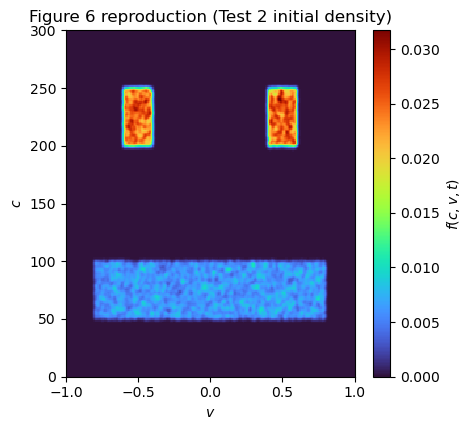

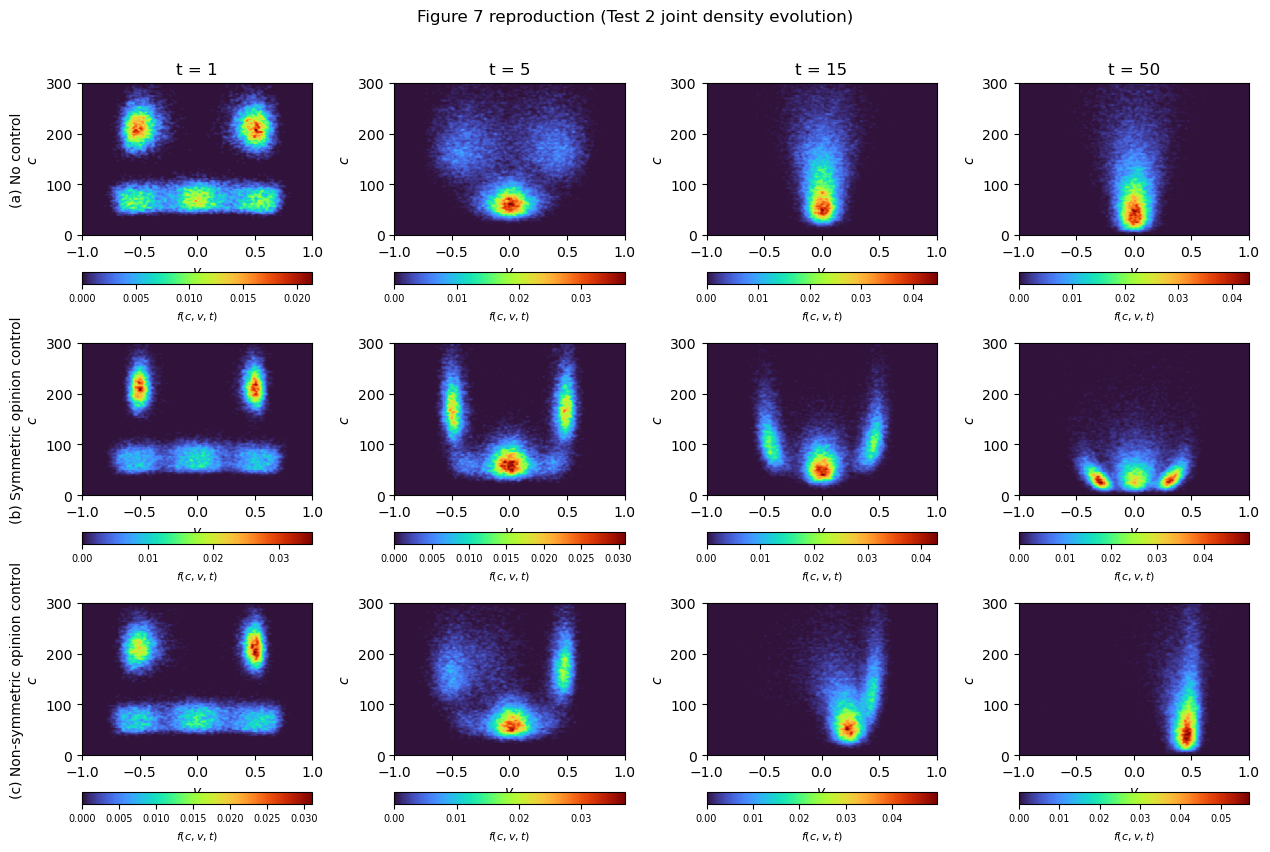

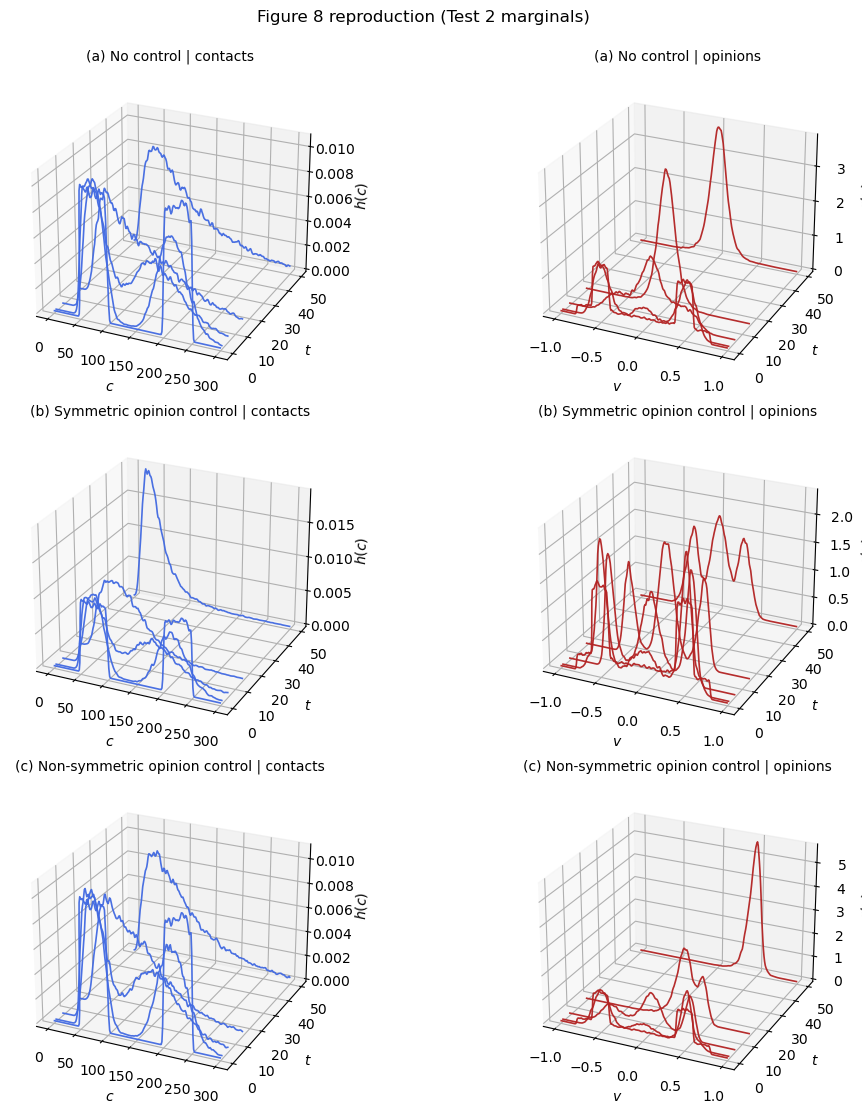

In [32]:
# 1) run the experiment (this computes the snapshots for a,b,c,d at t=1,5,15,50)
exp5 = run_test2(mode="balanced", seed=1234, progress=True, variant="figure")

# 2) build all Test 2 figures (includes Figure 6 grid)
figs = plot_test2_all(exp5)

# 3) show Figure 6
figs["fig6"].show()
plt.show()